In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [2]:
geom_mean = lambda x: np.exp(np.mean(np.log(x)))

In [3]:
with open('data/river_solute_tracer_data.csv', 'r') as file:
    data_reader = csv.reader(file)
    data_mat = [[cell for cell in row] for row in data_reader]
    breakthrough_curves_data = [[[data_mat[i][i_btc*5+j] for i in range(len(data_mat))] for j in range(4)] for i_btc in range(len(data_mat[0])//5)]

In [5]:
ts_m = [np.array([float(c) for c in btc[0][33:] if c!='']) for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
btcs_m = [np.array([float(c) for c in btc[3][33:] if c!='']) for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
xs_m = [btc[2][18] for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
xs_m = np.array([float(i) if i!='' else 0.0 for i in xs_m])
background_cs_m = [btc[2][25] for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
background_cs_m = [float(i) if i!='' else 0.0 for i in background_cs_m]
names_list = [btc[0][31] for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
n_btcs = len(ts_m)
rivers_list = [n.split(' ')[0] for n in names_list]
rivers_full_name_list = [btc[2][1] for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
dates_list = [btc[2][27] for btc in breakthrough_curves_data if len([float(c) for c in btc[3][33:] if c!=''])>0 and btc[2][18] not in ['','0'] and btc[2][26] in ['','0','0.0']]
tracers_list = [' '.join(n.split(' ')[:2])+' '+''.join([j  if ('S'+j in n.split(' ')[-1]) else '' for j in list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')]) for n in names_list]
unique_tracers_list = list(set(tracers_list))
_,count_tracers = np.unique([unique_tracers_list.index(i) for i in tracers_list], return_counts = True)
index_experiments = [[i_btcs for i_btcs in range(n_btcs) if tracers_list[i_btcs] == uniq] for uniq in unique_tracers_list]

In [6]:
for i_btc in range(n_btcs):
    if len(ts_m[i_btc])<len(btcs_m[i_btc]):
        btcs_m[i_btc] = btcs_m[i_btc][:len(ts_m[i_btc])]
T_= int(max([t[-1]/t[np.argmax(btc)] for t,btc in zip(ts_m,btcs_m)]))+1
print(T_)
Nt = 150

24


In [7]:

ts_m_0 = []
btcs_m_0 = []
for i_btc in range(n_btcs):
    t,btc = ts_m[i_btc],btcs_m[i_btc]
    sorted_indices = np.argsort(t)
    t = t[sorted_indices]
    btc = btc[sorted_indices]
    t_unique,indices_unique = np.unique(t, return_index=True)
    if len(t_unique)!=len(t):
        btc_unique = np.zeros(len(indices_unique))
        for i in range(len(indices_unique)):
            if i<len(indices_unique)-1:
                btc_unique[i] = np.mean(btc[indices_unique[i]:indices_unique[i+1]])
            else:
                btc_unique[i] = np.mean(btc[indices_unique[i]:])
        t = t_unique
        btc = btc_unique
    deltat = np.max(t[1:]-t[:-1])
    t_ext = np.concatenate((np.arange(t[0],0,-deltat)[1:][::-1],t,np.arange(t[-1],T_*t[np.argmax(btc)],deltat)[1:]))
    btc_ext = np.interp(t_ext,t,btc-background_cs_m[i_btc],left = 0.0,right = 0.0)
    btc_ext_0 = btc_ext.copy()
    while np.any((np.gradient(t_ext)/t_ext[np.argmax(btc_ext)])<1/(1.5*Nt)):
        btc_ext = btc_ext[np.logical_or((~((np.gradient(t_ext)/t_ext[np.argmax(btc_ext_0)])<1/(1.3*Nt))),np.arange(len(t_ext))%2==0)]
        t_ext = t_ext[np.logical_or((~((np.gradient(t_ext)/t_ext[np.argmax(btc_ext_0)])<1/(1.3*Nt))),np.arange(len(t_ext))%2==0)]
    ts_m_0.append(t_ext)
    btcs_m_0.append(btc_ext)

In [8]:
vs_peak = np.array([x/ts_meas[np.argmax(measured_bt)] for ts_meas,measured_bt,x in zip(ts_m,btcs_m,xs_m)])

## Params ADE

In [9]:
def ADE(x,t,v,D):
    return 1/(np.sqrt(4*np.pi*D*t))*np.exp(-(x-v*t)**2/(4*D*t))

In [10]:
import scipy
params_ADE = np.zeros((n_btcs,4))
for i_btc in range(n_btcs):
    t,btc,x = ts_m_0[i_btc],btcs_m_0[i_btc],xs_m[i_btc]

    ## ADE
    tmax = t[np.argmax(btc)]
    alpha = 1
    for i in range(4):
        v_peak = x / tmax * alpha
        gamma = np.gradient(np.gradient(btc,t),t)[np.argmax(btc)]/np.max(btc)
        D_peak = (alpha*(alpha**2-3)*v_peak**3*x-np.sqrt(4*alpha**4*(alpha**2 - 1)**2 *gamma * v_peak**4 * x**4 - 2 * alpha**2 *(alpha**4 - 3) * v_peak**6 * x**2))/ (2*alpha**2*(4*gamma*alpha**2*x**2-3*v_peak**2))
        Pe = x*v_peak/D_peak
        alpha = np.sqrt(1/Pe**2+1)-1/Pe
    if t[0]==0:
        v_ls, D_ls = scipy.optimize.least_squares(lambda params: ADE(x,t[1:],params[0],params[1])/np.trapz(ADE(x,t[1:],params[0],params[1]))*np.trapz(btc[1:])-btc[1:],np.array([v_peak,D_peak]),bounds=(0, np.inf)).x
    else:
        v_ls, D_ls = scipy.optimize.least_squares(lambda params: ADE(x,t,params[0],params[1])/np.trapz(ADE(x,t,params[0],params[1]))*np.trapz(btc)-btc,np.array([v_peak,D_peak]),bounds=(0, np.inf)).x
    params_ADE[i_btc] = np.array([v_ls,v_ls*x/D_ls,v_peak,v_peak*x/D_peak])

# Parameter analysis

In [11]:
memory_funcs = ['first order','power law']
bound_conds = ['semi-infinite-conc','semi-infinite-mixed','infinite']
all_dic_results_short = {memory_func:{} for memory_func in memory_funcs}
for memory_func in memory_funcs:
    for bound_cond in bound_conds:
        all_dic_results_short[memory_func][bound_cond] = np.load('results-'+bound_cond+'-'+memory_func+'-0_output.npy',allow_pickle=True).item()

In [12]:
import pandas as pd
# Create a DataFrame with appropriate column labels
params_data = np.vstack(np.vstack(np.array([[all_dic_results_short[i][j]['Estimated parameters']['LIPO, best initial'].T for j in bound_conds]for i in memory_funcs])))
df = pd.DataFrame(params_data.T, index=names_list)
header1 = [(i+', '+j)*(k==0) for i in memory_funcs for j in bound_conds for k in range(4)]
header2 = ['v','Pe','beta*k_hat_f','k_hat_r']*3+['v','Pe','beta*alpha_hat','1-gamma']*3
# Create a MultiIndex for columns
multi_index = pd.MultiIndex.from_arrays([header1, header2])
df.columns = multi_index
df.to_csv('estimated_parameters_breakthrough_curves.csv', index=False)

array([0.97664102, 0.9970283 , 1.0125277 , 1.01424836, 1.01591972,
       1.02902923, 1.03239635, 1.029     ])

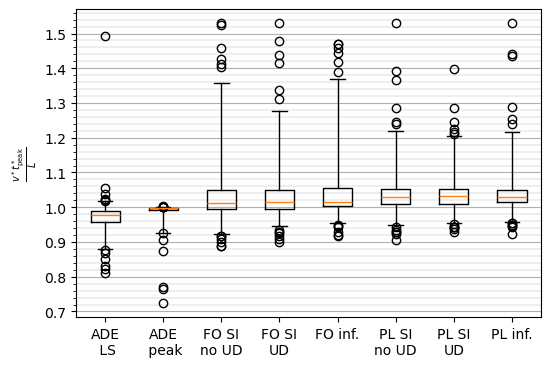

In [20]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot([params_ADE[:,0]/vs_peak,params_ADE[:,2]/vs_peak]+[all_dic_results_short[i][j]['Estimated parameters']['LIPO, best initial'][:,0]/vs_peak for i in memory_funcs for j in bound_conds],
           labels = ['ADE\n LS', 'ADE\n peak', 'FO SI\nno UD', 'FO SI\nUD', 'FO inf.', 'PL SI\nno UD', 'PL SI\nUD', 'PL inf.'], whis=[2, 98])
ax.grid(axis = 'y')
ax.yaxis.set_major_locator(ticker.AutoLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis = 'y', which='minor',linewidth = 0.3)
ax.set_ylabel(r'$\frac{v^* t^*_{\text{peak}}}{L}$')
np.median([params_ADE[:,0]/vs_peak,params_ADE[:,2]/vs_peak]+[all_dic_results_short[i][j]['Estimated parameters']['LIPO, best initial'][:,0]/vs_peak for i in memory_funcs for j in bound_conds], axis = 1)

In [21]:
mean_ts = np.array([np.trapz(ts_m[i_btc]*btcs_m[i_btc], x=ts_m[i_btc])/np.trapz(btcs_m[i_btc], x=ts_m[i_btc]) for i_btc in range(n_btcs)])
sigma_ts = np.array([np.sqrt(np.trapz((ts_m[i_btc]-mean_ts[i_btc])**2*btcs_m[i_btc], x=ts_m[i_btc])/np.trapz(btcs_m[i_btc], x=ts_m[i_btc])) for i_btc in range(n_btcs)])
Pe_sigma_est = 2 * xs_m**2/(vs_peak**2 * sigma_ts**2)

([2.5289092470978565,
  4.037603204220861,
  9.03636793724011,
  8.817483700204809,
  9.094828009829365,
  5.513308052926288,
  5.4664874461961075,
  5.442425518692741],
 array([2.00016759, 2.97875305, 6.91104526, 7.13115786, 7.10206686,
        4.16572483, 4.15279129, 4.11927986]))

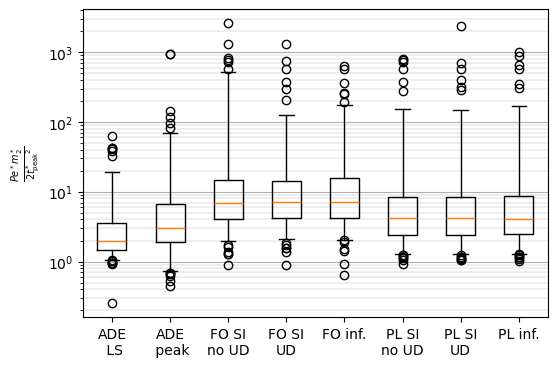

In [22]:
import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot([(params_ADE[:,1])/Pe_sigma_est,params_ADE[:,3]/Pe_sigma_est]+[all_dic_results_short[i][j]['Estimated parameters']['LIPO, best initial'][:,1]/Pe_sigma_est for i in memory_funcs for j in bound_conds],
           labels = ['ADE\n LS', 'ADE\n peak', 'FO SI\nno UD', 'FO SI\nUD', 'FO inf.', 'PL SI\nno UD', 'PL SI\nUD', 'PL inf.'], whis=[2, 98])
ax.grid(axis = 'y')
ax.set_yscale('log')
# ax.yaxis.set_major_locator(ticker.AutoLocator())
# ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis = 'y', which='minor',linewidth = 0.3)
ax.set_ylabel(r'$\frac{Pe^* m_2^*}{2 {t^*_{\text{peak}}}^2}$')
[geom_mean((params_ADE[:,1])/Pe_sigma_est),geom_mean(params_ADE[:,3]/Pe_sigma_est)]+[geom_mean(all_dic_results_short[i][j]['Estimated parameters']['LIPO, best initial'][:,1]/Pe_sigma_est) for i in memory_funcs for j in bound_conds],np.median([(params_ADE[:,1]/Pe_sigma_est),(params_ADE[:,3]/Pe_sigma_est)]+[(all_dic_results_short[i][j]['Estimated parameters']['LIPO, best initial'][:,1]/Pe_sigma_est) for i in memory_funcs for j in bound_conds],axis = 1)

## First order infinite analysis

In [23]:
params = all_dic_results_short['first order']['infinite']['Estimated parameters']['LIPO, best initial']

In [24]:
k_rs = all_dic_results_short['first order']['infinite']['Estimated parameters']['LIPO, best initial'][:,3]*all_dic_results_short['first order']['infinite']['Estimated parameters']['LIPO, best initial'][:,0]/xs_m
beta_k_fs = all_dic_results_short['first order']['infinite']['Estimated parameters']['LIPO, best initial'][:,2]*all_dic_results_short['first order']['infinite']['Estimated parameters']['LIPO, best initial'][:,0]/xs_m

In [25]:
m3 = np.array([np.sqrt(np.trapz((ts_m[i_btc]-mean_ts[i_btc])**3*btcs_m[i_btc], x=ts_m[i_btc])/np.trapz(btcs_m[i_btc], x=ts_m[i_btc])) for i_btc in range(n_btcs)])

C:\Users\manue\AppData\Local\Temp\ipykernel_24792\3083668886.py:1: RuntimeWarning: invalid value encountered in sqrt
  m3 = np.array([np.sqrt(np.trapz((ts_m[i_btc]-mean_ts[i_btc])**3*btcs_m[i_btc], x=ts_m[i_btc])/np.trapz(btcs_m[i_btc], x=ts_m[i_btc])) for i_btc in range(n_btcs)])


In [26]:
sk2_x = (m3**2/sigma_ts**3 * xs_m)

0.7424648167743836 1.0


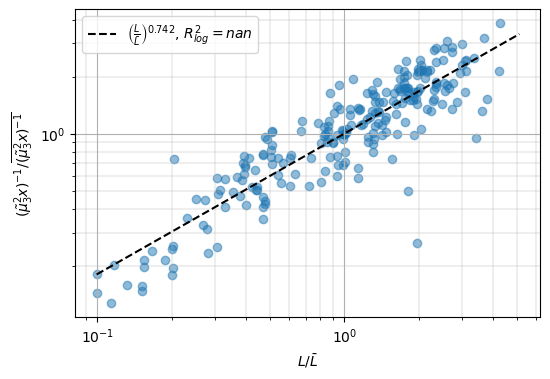

In [27]:
fig = plt.figure(figsize = (6,4))
ax = plt.gca()

distances_normalized = np.array([])
sk2_x_normalized = np.array([])
for ind_exp in index_experiments:
    ax.scatter((xs_m)[ind_exp]/np.exp(np.mean(np.log((xs_m)[ind_exp]))),sk2_x[ind_exp]/np.exp(np.mean(np.log(sk2_x[ind_exp]))),linewidth =1, c = 'tab:blue',alpha = 0.5)
    distances_normalized = np.concatenate((distances_normalized,(xs_m)[ind_exp]/np.exp(np.mean(np.log((xs_m)[ind_exp])))))
    sk2_x_normalized = np.concatenate((sk2_x_normalized,(sk2_x)[ind_exp]/np.exp(np.mean(np.log((sk2_x)[ind_exp])))))


m,b = np.polyfit(np.log(distances_normalized[~np.isnan(sk2_x_normalized)]), np.log(sk2_x_normalized[~np.isnan(sk2_x_normalized)]), 1)
print(m,np.exp(b))
logR2 = 1-np.sum((np.log(sk2_x_normalized)-(b+m*np.log(distances_normalized)))**2)/np.sum((np.log(sk2_x_normalized)-np.mean(np.log(sk2_x_normalized)))**2)
ax.plot(np.array([np.min(distances_normalized),np.max(distances_normalized)]),np.exp(b)*np.array([np.min(distances_normalized),np.max(distances_normalized)])**m,c = 'k', linestyle = 'dashed', label = r'$ \left(\frac{L}{\bar{L}} \right)^{'+format(m,'.3')+'}$, $R_{log}^2='+format(logR2,'.3')+'$')

ax.grid(which='major')
ax.grid(which='minor',linewidth = 0.3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$L/\bar{L}$')
ax.set_ylabel(r'$(\tilde{\mu}_3^2x)^{-1}/\overline{(\tilde{\mu}_3^2x)^{-1}}$')
ax.legend()

-0.8425722857748866 1.0


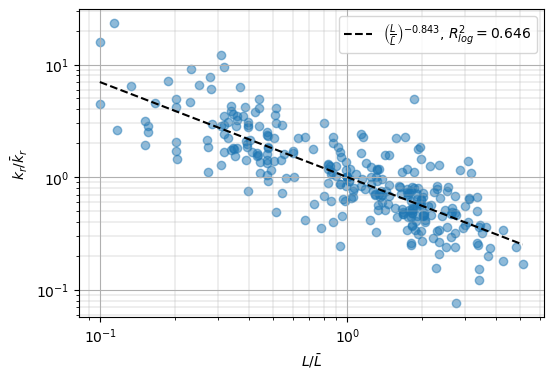

In [28]:
fig = plt.figure(figsize = (6,4))
ax = plt.gca()

distances_normalized = np.array([])
k_r_normalized = np.array([])
for ind_exp in index_experiments:
    ax.scatter((xs_m)[ind_exp]/np.exp(np.mean(np.log((xs_m)[ind_exp]))),k_rs[ind_exp]/np.exp(np.mean(np.log(k_rs[ind_exp]))),linewidth =1, c = 'tab:blue',alpha = 0.5)
    distances_normalized = np.concatenate((distances_normalized,(xs_m)[ind_exp]/np.exp(np.mean(np.log((xs_m)[ind_exp])))))
    k_r_normalized = np.concatenate((k_r_normalized,(k_rs)[ind_exp]/np.exp(np.mean(np.log((k_rs)[ind_exp])))))


m,b = np.polyfit(np.log(distances_normalized), np.log(k_r_normalized), 1)
print(m,np.exp(b))
logR2 = 1-np.sum((np.log(k_r_normalized)-(b+m*np.log(distances_normalized)))**2)/np.sum((np.log(k_r_normalized)-np.mean(np.log(k_r_normalized)))**2)
ax.plot(np.array([np.min(distances_normalized),np.max(distances_normalized)]),np.exp(b)*np.array([np.min(distances_normalized),np.max(distances_normalized)])**m,c = 'k', linestyle = 'dashed', label = r'$ \left(\frac{L}{\bar{L}} \right)^{'+format(m,'.3')+'}$, $R_{log}^2='+format(logR2,'.3')+'$')

ax.grid(which='major')
ax.grid(which='minor',linewidth = 0.3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$L/\bar{L}$')
ax.set_ylabel(r'$k_r/\bar{k}_r$')
ax.legend()

1.2313448384851156 0.08307881086036457


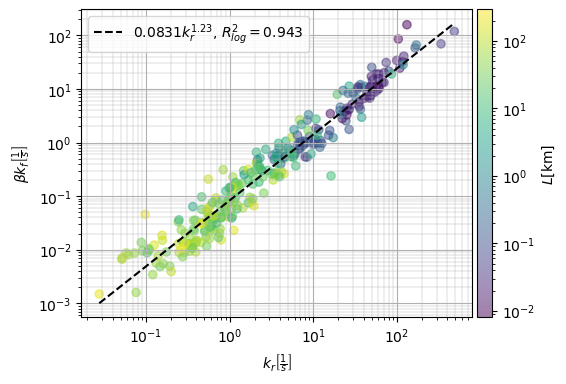

In [30]:
fig = plt.figure(figsize = (6,4))
ax = plt.gca()
m,b = np.polyfit(np.log(k_rs), np.log(beta_k_fs), 1)
logR2 = 1-np.sum((np.log(beta_k_fs)-(b+m*np.log(k_rs)))**2)/np.sum((np.log(beta_k_fs)-np.mean(np.log(beta_k_fs)))**2)
print(m,np.exp(b))
ax.plot(np.array([np.min(k_rs),np.max(k_rs)]),np.exp(b)*np.array([np.min(k_rs),np.max(k_rs)])**m,c = 'k', linestyle = 'dashed', label = '$'+format(np.exp(b),'.3')+'k_r^{'+format(m,'.3')+'}$, $R_{log}^2='+format(logR2,'.3')+'$')
scatter_plot = ax.scatter(k_rs,beta_k_fs, c = xs_m, norm=matplotlib.colors.LogNorm(), alpha = .5)
cbar = fig.colorbar(scatter_plot,pad = 0.01)
cbar.ax.set_ylabel(r'$L\left[\text{km}\right]$ ')
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(which='major')
ax.grid(which='minor',linewidth = 0.3)
ax.set_xlabel(r'$k_r \left[\frac{1}{s}\right]$')
ax.set_ylabel(r'$\beta k_f \left[\frac{1}{s}\right]$')
ax.legend()

## Power law infinite analysis

In [31]:
gammas = 1-all_dic_results_short['power law']['infinite']['Estimated parameters']['LIPO, best initial'][:,3]
beta_alphas = all_dic_results_short['power law']['infinite']['Estimated parameters']['LIPO, best initial'][:,2]*(all_dic_results_short['power law']['infinite']['Estimated parameters']['LIPO, best initial'][:,0]/xs_m)**(gammas-1)

-0.04490027989595884 1.0


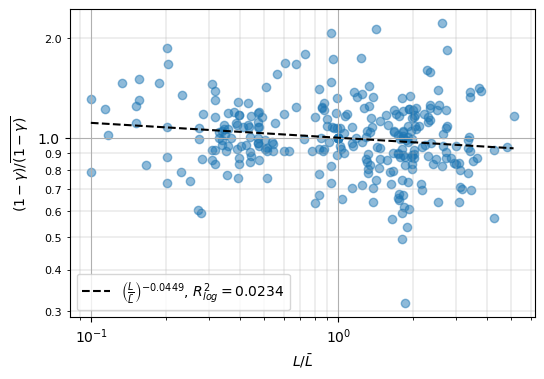

In [32]:
fig = plt.figure(figsize = (6,4))
ax = plt.gca()

distances_normalized = np.array([])
gammas_comp_normalized = np.array([])
for ind_exp in index_experiments:
    ax.scatter((xs_m)[ind_exp]/np.exp(np.mean(np.log((xs_m)[ind_exp]))),(1-gammas[ind_exp])/np.exp(np.mean(np.log(1-gammas[ind_exp]))),linewidth =1, c = 'tab:blue',alpha = 0.5)
    distances_normalized = np.concatenate((distances_normalized,(xs_m)[ind_exp]/np.exp(np.mean(np.log((xs_m)[ind_exp])))))
    gammas_comp_normalized = np.concatenate((gammas_comp_normalized,(1-gammas)[ind_exp]/np.exp(np.mean(np.log((1-gammas)[ind_exp])))))


m,b = np.polyfit(np.log(distances_normalized), np.log(gammas_comp_normalized), 1)
print(m,np.exp(b))
logR2 = 1-np.sum((np.log(gammas_comp_normalized)-(b+m*np.log(distances_normalized)))**2)/np.sum((np.log(gammas_comp_normalized)-np.mean(np.log(gammas_comp_normalized)))**2)
ax.plot(np.array([np.min(distances_normalized),np.max(distances_normalized)]),np.exp(b)*np.array([np.min(distances_normalized),np.max(distances_normalized)])**m,c = 'k', linestyle = 'dashed', label = r'$ \left(\frac{L}{\bar{L}} \right)^{'+format(m,'.3')+'}$, $R_{log}^2='+format(logR2,'.3')+'$')

ax.grid(which='major')
ax.grid(which='minor',linewidth = 0.3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$L/\bar{L}$')
ax.set_ylabel(r'$(1-\gamma)/\overline{(1-\gamma)}$')
ax.legend()
import matplotlib.ticker as mticker
# Remove scientific notation
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.1f}'))
ax.yaxis.set_minor_formatter(mticker.StrMethodFormatter('{x:.1f}'))
ax.tick_params(axis='y', labelsize=8.0, which='minor')


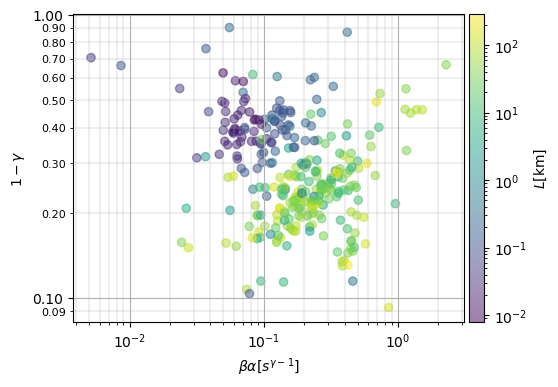

In [33]:
fig = plt.figure(figsize = (6,4))
ax = plt.gca()
scatter_plot = ax.scatter(beta_alphas,1-gammas, c = xs_m, norm=matplotlib.colors.LogNorm(), alpha = 0.5)
cbar = fig.colorbar(scatter_plot,pad = 0.01)
cbar.ax.set_ylabel(r'$L\left[\text{km}\right]$ ')
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(which='major')
ax.grid(which='minor',linewidth = 0.3)
ax.set_xlabel(r'$\beta \alpha \left[s^{\gamma-1}\right]$')
ax.set_ylabel(r'$1-\gamma$')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:.2f}'))
ax.yaxis.set_minor_formatter(mticker.StrMethodFormatter('{x:.2f}'))
ax.tick_params(axis='y', labelsize=8.0, which='minor')

## Errors analysis

In [34]:
seeds = ['0','1','2','3']

In [35]:
memory_func = memory_funcs[0]
all_dic_results_no_LIPO = {}
for seed in seeds:
    all_dic_results_no_LIPO[seed] = np.load('results-infinite-'+memory_func+'-'+seed+'_output.npy',allow_pickle=True).item()

In [36]:
# Since LIPO takes long, it is only computed in the case of seed 0
dic_results_LIPO = np.load('results-infinite-'+memory_func+'-0_output.npy'.npy',allow_pickle=True).item()

In [38]:
if memory_func == memory_funcs[0]:
    keys = ['Moments', 'Laplace','LIPO', 'NNI', 'PBI', 'KL-DNN-MAP', 'Inverse KL-DNN augmented', 'LIPO, best initial']
else:
    keys = ['Laplace','LIPO', 'NNI', 'PBI', 'KL-DNN-MAP', 'Inverse KL-DNN augmented', 'LIPO, best initial']
label_dict = {'Moments': 'Mom. matching', 'Laplace': 'Lap. dom. fitting', 'NNI': 'DSTE-KL-NNI', 'PBI': 'DSTE-KL-PBI', 'Inverse KL-DNN augmented': 'DSTE-KL-IDNN', 'KL-DNN-MAP': 'DSTE-KL-FDNN', 'LIPO': 'LIPO, $N_{ev} = 1000$', 'LIPO, best initial': 'DSTE-KL-PBI ref. w/ LIPO, $N_{ev} = 300$'}
color_dict = {'Moments': 'tab:blue', 'Laplace': 'tab:orange', 'NNI': 'tab:pink', 'PBI': 'tab:green', 'Inverse KL-DNN augmented': 'tab:red', 'KL-DNN-MAP': 'tab:red', 'LIPO': 'tab:purple', 'LIPO, best initial': 'tab:cyan'}
linestyle_dict = {'Moments': 'solid', 'Laplace': 'solid', 'NNI': 'solid', 'PBI': 'solid', 'Inverse KL-DNN augmented': 'dashed', 'KL-DNN-MAP': 'solid', 'LIPO': 'solid', 'LIPO, best initial': 'solid'}
zorder_dict = {'Moments': 0, 'Laplace': 1, 'NNI': 2, 'PBI': 8, 'Inverse KL-DNN augmented': 3, 'KL-DNN-MAP': 4, 'LIPO': 5, 'LIPO, best initial': 7}

Moments train 0.113% 0.000% 5.27% 0.00%
Moments test 0.167% 0.000% 8.72% 0.00%
Laplace train 0.169% 0.000% 30.56% 0.00%
Laplace test 0.216% 0.000% 13.80% 0.00%
LIPO train 0.046% 4.40%
LIPO test 0.102% 5.32%
NNI train 0.037% 16.636% 2.37% 47.40%
NNI test 0.062% 13.486% 2.11% 59.72%
PBI train 0.032% 17.073% 2.38% 43.30%
PBI test 0.053% 16.514% 1.84% 44.92%
KL-DNN-MAP train 0.032% 12.883% 2.29% 35.57%
KL-DNN-MAP test 0.055% 9.745% 1.34% 41.17%
Inverse KL-DNN augmented train 0.037% 19.262% 2.17% 43.95%
Inverse KL-DNN augmented test 0.057% 19.129% 1.19% 43.61%
LIPO, best initial train 0.022% 1.21%
LIPO, best initial test 0.038% 0.64%
Inverse KL-DNN 0.049% 24.921% 2.19% 0.83%


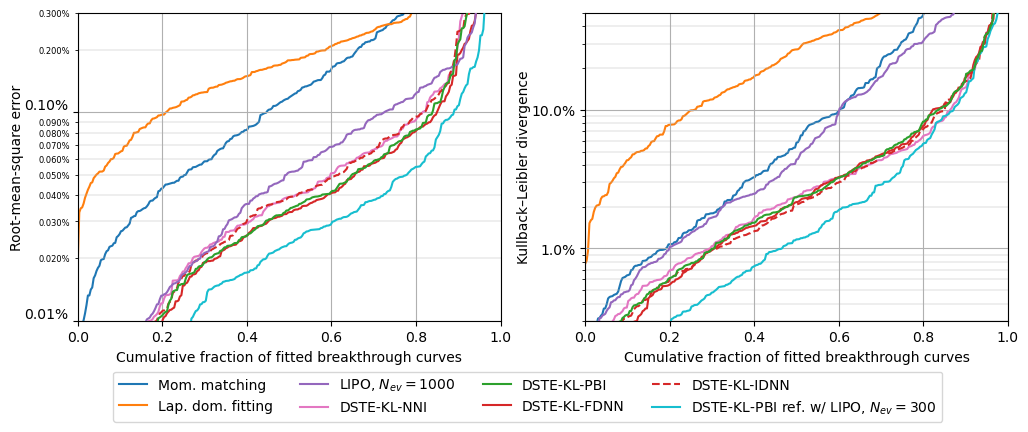

In [39]:
import matplotlib
fig,axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
train_indices = all_dic_results_no_LIPO['']['Train indices']
test_indices = np.delete(np.arange(n_btcs),train_indices)
for key in keys:
    if key in ['LIPO','LIPO, best initial']:
        RMSEs_LIPO = dic_results_LIPO['Errors in reconstruction of breakthrough curves']['RMSE'][key]
        axes[0].semilogy(np.linspace(0,1,n_btcs),np.sort(RMSEs_LIPO), label = label_dict[key] , c = color_dict[key], linestyle = linestyle_dict[key], zorder = zorder_dict[key])
        KL_divs_LIPO = dic_results_LIPO['Errors in reconstruction of breakthrough curves']['KL divergence'][key]
        axes[1].semilogy(np.linspace(0,1,n_btcs),np.sort(KL_divs_LIPO), label = label_dict[key] , c = color_dict[key], linestyle = linestyle_dict[key], zorder = zorder_dict[key])
        mean_values = [np.median(RMSEs_LIPO[train_indices]),np.median(KL_divs_LIPO[train_indices][KL_divs_LIPO[train_indices]>0]),
                       np.median(RMSEs_LIPO[test_indices]),np.median(KL_divs_LIPO[test_indices][KL_divs_LIPO[test_indices]>0])]
        print(key,'train',format(mean_values[0],'.3%'),format(mean_values[1],'.2%'))
        print(key,'test',format(mean_values[2],'.3%'),format(mean_values[3],'.2%'))
    else:
        RMSEs_i = np.array([all_dic_results_no_LIPO[seed]['Errors in reconstruction of breakthrough curves']['RMSE'][key] for seed in seeds])
        axes[0].semilogy(np.linspace(0,1,n_btcs),np.sort(np.mean(RMSEs_i,axis = 0)), label = label_dict[key] , c = color_dict[key], linestyle = linestyle_dict[key], zorder = zorder_dict[key])
        KL_divs_i = np.array([all_dic_results_no_LIPO[seed]['Errors in reconstruction of breakthrough curves']['KL divergence'][key] for seed in seeds])
        axes[1].semilogy(np.linspace(0,1,n_btcs),np.sort(np.mean(KL_divs_i,axis = 0)), label = label_dict[key] , c = color_dict[key], linestyle = linestyle_dict[key], zorder = zorder_dict[key])
        mean_values = [np.median(np.mean(RMSEs_i,axis = 0)[train_indices]),np.median((np.var(RMSEs_i,axis = 0,ddof = 1)**(1/2)/np.mean(RMSEs_i,axis = 0))[train_indices]),
                       np.median(np.mean(KL_divs_i,axis = 0)[train_indices][np.mean(KL_divs_i,axis = 0)[train_indices]>0]),np.median((np.var(KL_divs_i,axis = 0,ddof = 1)**(1/2)/np.mean(KL_divs_i,axis = 0))[train_indices]),
                      np.median(np.mean(RMSEs_i,axis = 0)[test_indices]),np.median((np.var(RMSEs_i,axis = 0,ddof = 1)**(1/2)/np.mean(RMSEs_i,axis = 0))[test_indices]),
                        np.median(np.mean(KL_divs_i,axis = 0)[test_indices][np.mean(KL_divs_i,axis = 0)[test_indices]>0]),np.median((np.var(KL_divs_i,axis = 0,ddof = 1)**(1/2)/np.mean(KL_divs_i,axis = 0))[test_indices])]
        print(key,'train',*[format(i,'.3%') for i in mean_values[0:2]],*[format(i,'.2%') for i in mean_values[2:4]])
        print(key,'test',*[format(i,'.3%') for i in mean_values[4:6]],*[format(i,'.2%') for i in mean_values[6:]])
  

key = 'Inverse KL-DNN'
RMSEs_i = np.array([all_dic_results_no_LIPO[seed]['Errors in reconstruction of breakthrough curves']['RMSE'][key] for seed in seeds])
KL_divs_i = np.array([all_dic_results_no_LIPO[seed]['Errors in reconstruction of breakthrough curves']['KL divergence'][key] for seed in seeds])
mean_values = [np.median(np.mean(RMSEs_i,axis = 0)),np.median(np.var(RMSEs_i,axis = 0,ddof = 1)**(1/2)/np.mean(RMSEs_i,axis = 0)),np.median(np.mean(KL_divs_i,axis = 0)),np.median(np.var(KL_divs_i,axis = 0,ddof = 1)**(1/2))]
print(key,*[format(i,'.3%') for i in mean_values[0:2]],*[format(i,'.2%') for i in mean_values[2:]])

axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(decimals = 2,xmax = 1))
axes[0].yaxis.set_minor_formatter(matplotlib.ticker.PercentFormatter(decimals = 3,xmax = 1))

axes[0].tick_params(axis='y', which='major', labelsize=10)
axes[0].tick_params(axis='y', which='minor', labelsize=6)
for label in axes[0].get_yticklabels():
    label.set_verticalalignment('bottom')
axes[0].set_ylim(0.0001,0.003)
axes[0].set_xlim(0,1)
axes[0].grid(which='major')
axes[0].grid(which='minor',linewidth = 0.3)
axes[0].set_xlabel('Cumulative fraction of fitted breakthrough curves')
axes[0].set_ylabel('Root-mean-square error', labelpad= 0)


axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(decimals = 1,xmax = 1))

axes[1].tick_params(axis='y', which='major', labelsize=10)
for label in axes[0].get_yticklabels():
    label.set_verticalalignment('bottom')

axes[1].set_ylim(0.003,0.5)
axes[1].set_xlim(0,1)
axes[1].grid(which='major')
axes[1].grid(which='minor',linewidth = 0.3)
axes[1].set_xlabel('Cumulative fraction of fitted breakthrough curves')
axes[1].set_ylabel('Kullback–Leibler divergence', labelpad= 0)

# Add a common legend at the bottom
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.16))

In [40]:
from forward.laplace import ADEMF_1D

In [42]:
if memory_func == memory_funcs[0]:
    keys_plot = ['Moments', 'Laplace', 'NNI', 'PBI', 'KL-DNN-MAP','LIPO, best initial']
else:
    keys_plot = ['Laplace', 'NNI', 'PBI', 'KL-DNN-MAP','LIPO, best initial']


In [43]:
t_ = np.linspace(0,24,150*24+1)[1:]

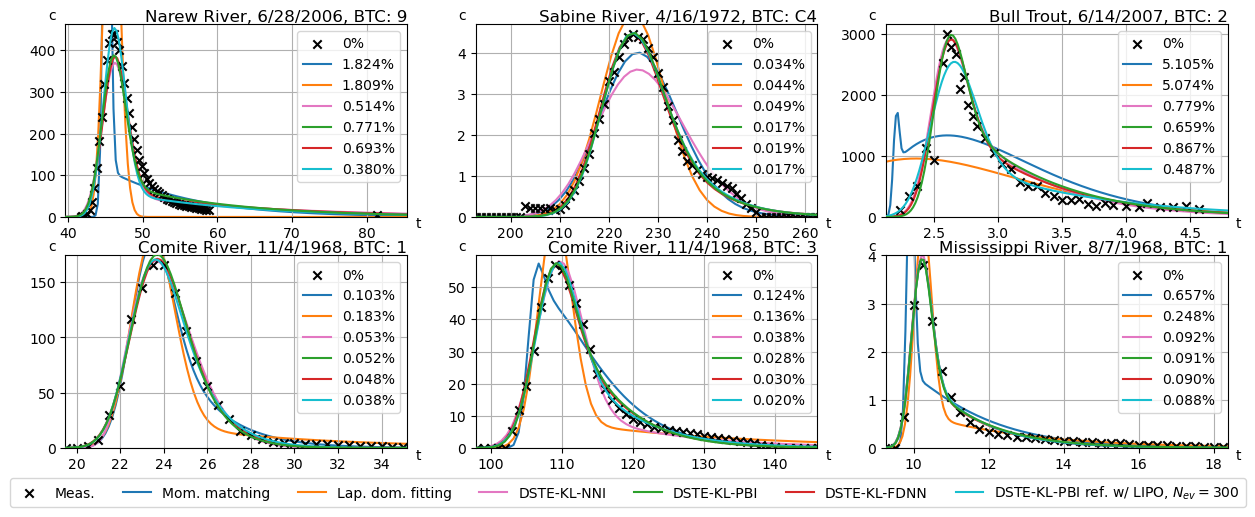

In [44]:
from matplotlib.transforms import offset_copy
np.random.seed(0)
Nrows = 2
Ncols = 3
fig,axes = plt.subplots(nrows = Nrows, ncols = Ncols, figsize = (15,5.5))
rand_i_btcs = np.sort(np.random.choice(list(range(n_btcs)),size = Nrows*Ncols, replace = False))
j=0
for i_btc in rand_i_btcs:
    
    t,btc,x = ts_m_0[i_btc],btcs_m_0[i_btc],xs_m[i_btc]
    axes[j//Ncols][j%Ncols].scatter(t,btc, c='k', marker = 'x', label = '0%', zorder = 6)
    axes[j//Ncols][j%Ncols].set_xlim(t[btc>np.max(btc)*0.001][0]*0.95,t[btc>np.max(btc)*0.01][-1]*1.05)
    axes[j//Ncols][j%Ncols].set_ylim(0.0,np.max(btc)*1.05)
    axes[j//Ncols][j%Ncols].set_title(rivers_full_name_list[i_btc]+', '+dates_list[i_btc]+', BTC: '+names_list[i_btc].split(' ')[2][1:], loc='right',pad = -50)
    for key in keys_plot:
        if key == 'LIPO, best initial':
            params = dic_results_LIPO['Estimated parameters'][key][i_btc]
            RMSE = dic_results_LIPO['Errors in reconstruction of breakthrough curves']['RMSE'][key][i_btc]
        else:
            params = all_dic_results_no_LIPO['']['Estimated parameters'][key][i_btc]
            RMSE = all_dic_results_no_LIPO['']['Errors in reconstruction of breakthrough curves']['RMSE'][key][i_btc]
        btc_rec = ADEMF_1D(t_*x/params[0],[x],params[0],params[1],params[2],[1,params[3]],memory_func,'infinite')[:,-1]
        axes[j//Ncols][j%Ncols].plot(t_*x/params[0],btc_rec*np.trapz(btc,t), c = color_dict[key], linestyle = linestyle_dict[key], zorder = zorder_dict[key], label = format(RMSE,'.3%'))
    axes[j//Ncols][j%Ncols].set_ylabel('c', rotation=0)
    axes[j//Ncols][j%Ncols].set_xlabel('t', loc='right', labelpad=-10)
    axes[j//Ncols][j%Ncols].grid()
    axes[j//Ncols][j%Ncols].yaxis.set_label_coords(-0.04,1.01)
    axes[j//Ncols][j%Ncols].xaxis.set_label_coords(1.04,0.0)
    axes[j//Ncols][j%Ncols].legend()
    j+=1
handles, _ = axes[0][0].get_legend_handles_labels()
labels = ['Meas.']+[label_dict[key] for key in keys_plot]
fig.legend(handles,labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.01))

In [45]:
params_ref = dic_results_LIPO['Estimated parameters']['LIPO, best initial']
for key in keys[:-1]:
    if key == 'LIPO':
        params = dic_results_LIPO['Estimated parameters'][key]
    elif key == 'NNI':
        params = dic_results_NNI['Estimated parameters'][key]
    else:
        params = all_dic_results_no_LIPO['']['Estimated parameters'][key]
    v_diff = np.median(np.abs(params[:,0]/params_ref[:,0]-1))
    Pe_diff = np.median(np.abs(1/params[:,1]-1/params_ref[:,1]))
    beta_prime_diff = np.median(np.abs(params[:,2]-params_ref[:,2]))
    mem_param_diff = np.median(np.abs(params[:,3]-params_ref[:,3]))
    print(key,format(v_diff,'.2%'),format(Pe_diff,'.2e'),format(beta_prime_diff,'.2e'),format(mem_param_diff,'.2e'))

Moments 4.43% 8.55e-04 1.09e+00 4.98e+00
Laplace 2.69% 4.50e-04 7.08e-01 2.38e+01
LIPO 2.35% 5.20e-04 6.14e-01 5.47e+00
NNI 1.14% 2.17e-04 2.92e-01 2.12e+00
PBI 0.79% 1.74e-04 2.31e-01 1.75e+00
KL-DNN-MAP 0.64% 1.64e-04 1.85e-01 1.45e+00
Inverse KL-DNN augmented 0.79% 1.81e-04 1.98e-01 1.54e+00
